In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import scipy.stats as stats
from scipy.stats import skew, kurtosis, anderson, shapiro


In [2]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [3]:
df.shape

(120000, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       120000 non-nul

In [5]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction_id      120000 non-null  object        
 1   transaction_date    120000 non-null  datetime64[ns]
 2   customer_id         120000 non-null  object        
 3   customer_gender     120000 non-null  object        
 4   customer_age_group  120000 non-null  object        
 5   customer_segment    120000 non-null  object        
 6   product_id          120000 non-null  object        
 7   product_name        120000 non-null  object        
 8   category            120000 non-null  object        
 9   brand               120000 non-null  object        
 10  quantity            120000 non-null  int64         
 11  unit_price          120000 non-null  float64       
 12  discount_pct        120000 non-null  int64         
 13  sales_amount        120000 no

In [6]:
df.isnull().sum()

transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

##### 1. Dataset have 120,000 rows and 17 columns<br>2. transaction_date need to convert to datetime format<br>3. there is no missing value and duplicate row and columns in the dataset<br>4. columns need to drop because give nothing information = transaction_id, transaction_date, customer_id & product_id

In [8]:
df1 = df.copy()
df1.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [9]:
df1.describe(include='all')

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
count,120000,120000,120000,120000,120000,120000,120000,120000,120000,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000,120000,120000
unique,120000,NaN,24784,3,5,4,120,40,8,3,NaN,NaN,NaN,NaN,5,3,5
top,T0000001,NaN,C023479,Female,35-44,VIP,P1016,Dumbbells,Sports,Brand 1,NaN,NaN,NaN,NaN,Credit Card,Mobile App,Central
freq,1,NaN,15,40268,24196,30115,1096,3108,15218,40240,NaN,NaN,NaN,NaN,24262,40204,24244
mean,NaN,2024-12-30 12:00:54.720000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.662908,240.621785,5.496500,377.975454,NaN,NaN,NaN
min,NaN,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,7.730000,0.000000,5.410000,NaN,NaN,NaN
25%,NaN,2024-06-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,102.010000,0.000000,136.860000,NaN,NaN,NaN
50%,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,238.750000,0.000000,295.980000,NaN,NaN,NaN
75%,NaN,2025-07-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,379.000000,10.000000,461.500000,NaN,NaN,NaN
max,NaN,2025-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,493.510000,30.000000,2467.550000,NaN,NaN,NaN


##### Mostly customer are female from age 35-44 and Comes from central<br>Most of them bought Dumbells from Brand 1<br>They are likely using Credit Card and Mobile App to buy

In [10]:
df1.drop(columns=['transaction_id', 'customer_id', 'product_id'], inplace=True)
df1.head()

,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,2024-04-24,Other,35-44,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,2025-07-12,Other,45-54,New,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,2025-06-01,Male,55+,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,2025-08-26,Male,25-34,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,2024-12-10,Male,45-54,New,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [11]:
num_col = df1.select_dtypes(include=np.number).columns
num_col.shape


(4,)

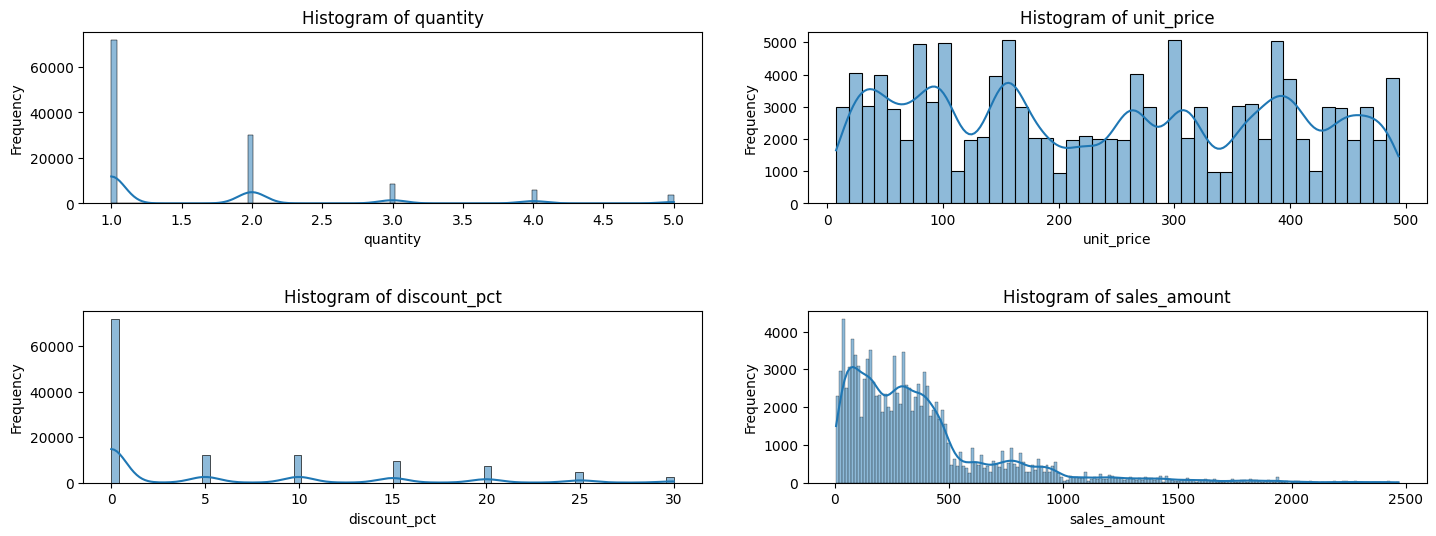

In [12]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(num_col,1):
    plt.subplot(2, 2, i)
    sns.histplot(df1[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout(pad=3)
plt.show()

In [13]:
df1.columns

Index(['transaction_date', 'customer_gender', 'customer_age_group',
       'customer_segment', 'product_name', 'category', 'brand', 'quantity',
       'unit_price', 'discount_pct', 'sales_amount', 'payment_method',
       'sales_channel', 'region'],
      dtype='object')

In [14]:
df1[num_col].skew().sort_values(ascending=False)

sales_amount    2.075947
quantity        1.692241
discount_pct    1.365003
unit_price      0.087601
dtype: float64

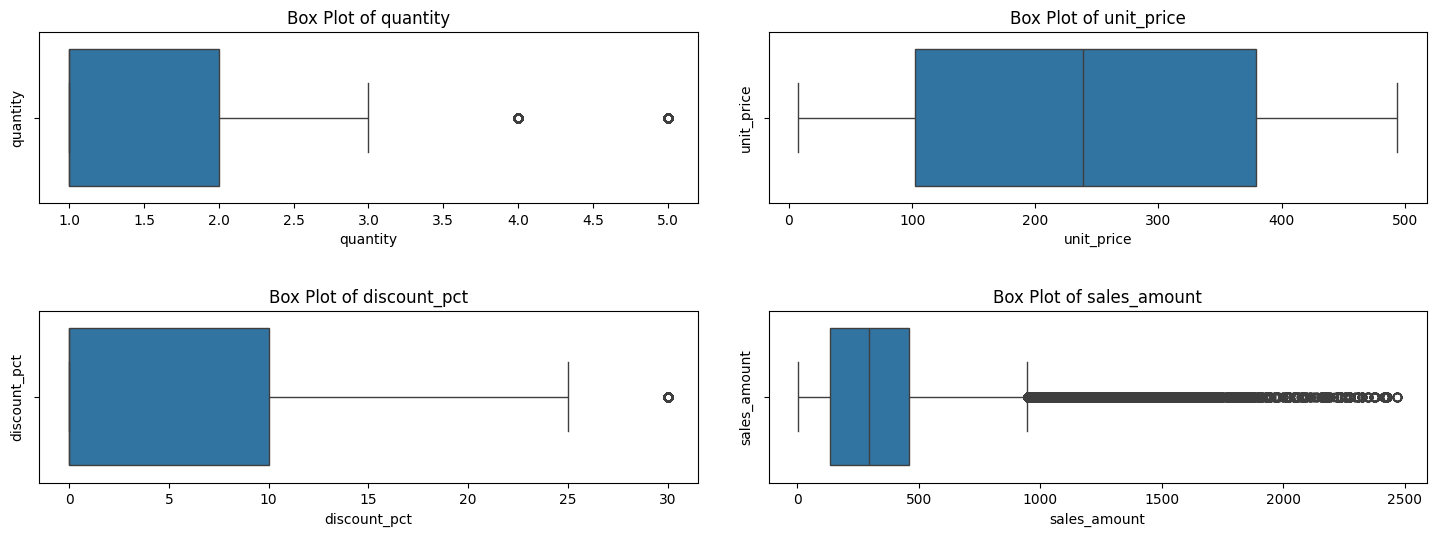

In [15]:
plt.figure(figsize=(15, 6))

for i, col in enumerate(num_col,1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df1[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout(pad=3)
plt.show()

In [16]:
q3, q1 = df1['sales_amount'].quantile([0.75, 0.25])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower Bound: {lower_bound}")
print(f"Number of outliers below lower bound: {len(df1[df1['sales_amount'] < lower_bound])}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of outliers above upper bound: {len(df1[df1['sales_amount'] > upper_bound])}")
print(f"Number of outliers in percentage: {((len(df1[df1['sales_amount'] < lower_bound]) + len(df1[df1['sales_amount'] > upper_bound])) / len(df1)) * 100:.2f}%")

Lower Bound: -350.09999999999997
Number of outliers below lower bound: 0
Upper Bound: 948.46
Number of outliers above upper bound: 8309
Number of outliers in percentage: 6.92%


##### 1. based on the histogram, there are discrete data for quantity, discount_pct column and unit_price<br>2. There are right-skew pattern these two histogram. they shows mostly customer bought 1 quantity without any discount/promotion<br>3. unit_price almost balance pattern<br>4. there are highly right-skew for sales_amount. Need to treat this skew and outlier

In [17]:
df1['sales_amount_log'] = np.log1p(df1['sales_amount'])

<Axes: xlabel='sales_amount_log', ylabel='Count'>

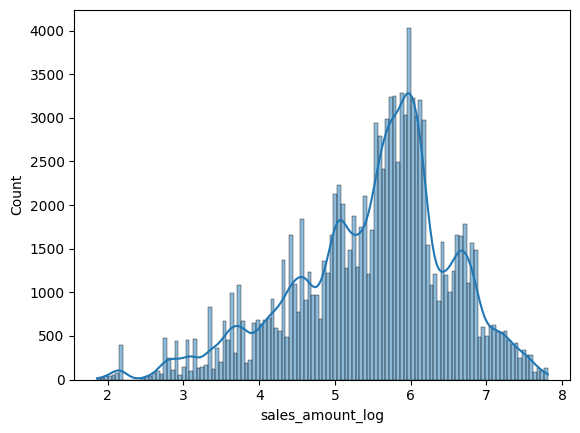

In [18]:
sns.histplot(df1['sales_amount_log'], kde=True)

<Axes: xlabel='sales_amount_log'>

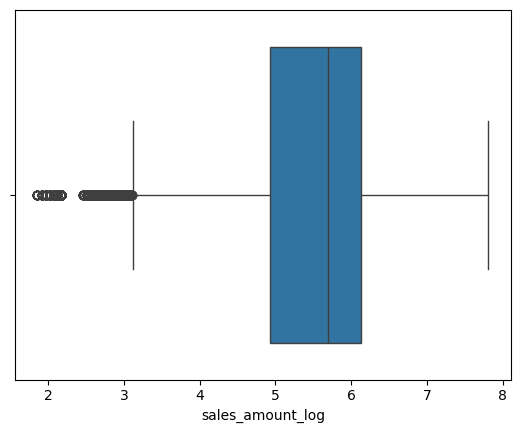

In [19]:
sns.boxplot(x=df1['sales_amount_log'])

In [20]:
df1['sales_amount_log'].skew()

np.float64(-0.6110166235995829)

Text(0.5, 1.0, 'Correlation Heatmap')

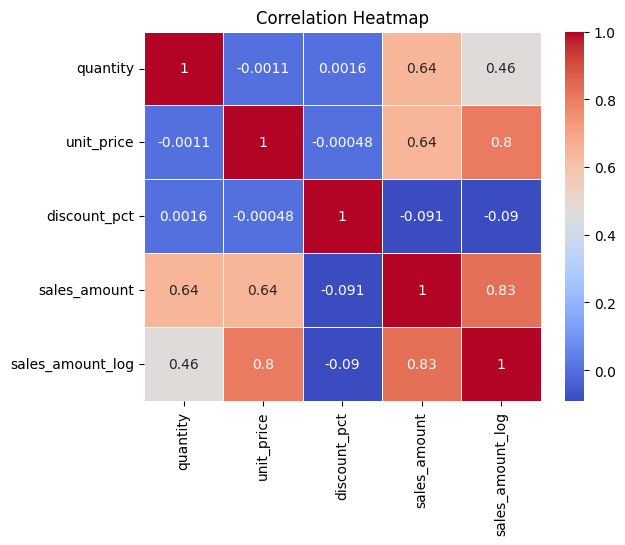

In [21]:
num_col = df1.select_dtypes(include=np.number).columns

sns.heatmap(df1[num_col].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

In [22]:
corr = df1[num_col].corr()['sales_amount_log'].sort_values(ascending=False)
corr

sales_amount_log    1.000000
sales_amount        0.826722
unit_price          0.803882
quantity            0.464546
discount_pct       -0.089509
Name: sales_amount_log, dtype: float64

##### 1. unit_price are highly positive correlated with sales amount log<br>2. quantity also are moderate positive correlated with sales_amount_log<br>3. discount_pct shows not correlation between sales_amount_log

In [23]:
df1.drop(columns='product_name', inplace=True)

In [24]:
cat_col = df1.select_dtypes(include='object').columns
cat_col.shape

(8,)

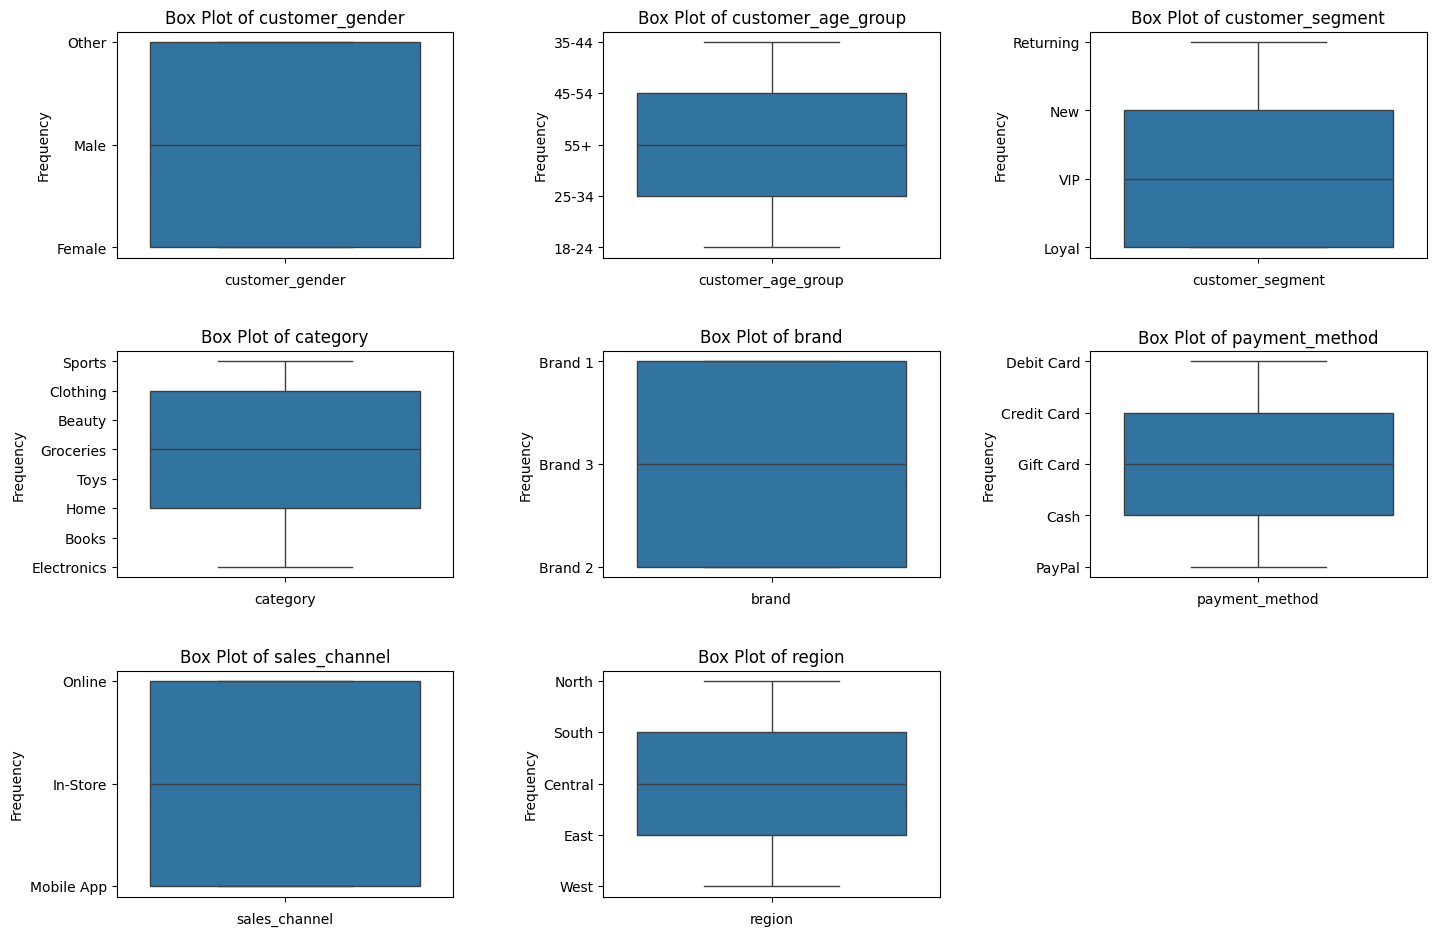

In [25]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(cat_col,1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df1[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout(pad=3)
plt.show()

In [26]:
df1[cat_col].describe()


,customer_gender,customer_age_group,customer_segment,category,brand,payment_method,sales_channel,region
count,120000,120000,120000,120000,120000,120000,120000,120000
unique,3,5,4,8,3,5,3,5
top,Female,35-44,VIP,Sports,Brand 1,Credit Card,Mobile App,Central
freq,40268,24196,30115,15218,40240,24262,40204,24244


In [27]:
from scipy.stats import ttest_ind, f_oneway

# =========================
# TARGET VARIABLE
# =========================
target = 'sales_amount_log'

# =========================
# CATEGORICAL COLUMNS
# =========================
cat_col = [
    'customer_gender',
    'customer_age_group',
    'customer_segment',
    'category',
    'brand',
    'payment_method',
    'sales_channel',
    'region'
]

# =========================
# LOOP TEST
# =========================

for col in cat_col:

    n_unique = df1[col].nunique()

    print("="*70)
    print(f"Column: {col}")
    print(f"Number of Categories: {n_unique}")

    # ==================================================
    # T-TEST (2 CATEGORY)
    # ==================================================
    if n_unique == 2:

        categories = df1[col].unique()

        group1 = df1[df1[col] == categories[0]][target]
        group2 = df1[df1[col] == categories[1]][target]

        t_stat, p_value = ttest_ind(group1, group2)

        print("\nT-TEST RESULT")
        print(f"T-Statistic : {t_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")

        if p_value < 0.05:
            print("Result      : Significant Difference")
        else:
            print("Result      : No Significant Difference")

    # ==================================================
    # ANOVA (>2 CATEGORY)
    # ==================================================
    elif n_unique > 2:

        groups = [
            df1[df1[col] == category][target]
            for category in df1[col].unique()
        ]

        f_stat, p_value = f_oneway(*groups)

        print("\nANOVA RESULT")
        print(f"F-Statistic : {f_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")

        if p_value < 0.05:
            print("Result      : Significant Difference")
        else:
            print("Result      : No Significant Difference")

Column: customer_gender
Number of Categories: 3

ANOVA RESULT
F-Statistic : 1.9973
P-Value     : 0.135707
Result      : No Significant Difference
Column: customer_age_group
Number of Categories: 5

ANOVA RESULT
F-Statistic : 0.5341
P-Value     : 0.710699
Result      : No Significant Difference
Column: customer_segment
Number of Categories: 4

ANOVA RESULT
F-Statistic : 0.2514
P-Value     : 0.860420
Result      : No Significant Difference
Column: category
Number of Categories: 8

ANOVA RESULT
F-Statistic : 168.6852
P-Value     : 0.000000
Result      : Significant Difference
Column: brand
Number of Categories: 3

ANOVA RESULT
F-Statistic : 166.0471
P-Value     : 0.000000
Result      : Significant Difference
Column: payment_method
Number of Categories: 5



ANOVA RESULT
F-Statistic : 0.0845
P-Value     : 0.987232
Result      : No Significant Difference
Column: sales_channel
Number of Categories: 3

ANOVA RESULT
F-Statistic : 2.7881
P-Value     : 0.061543
Result      : No Significant Difference
Column: region
Number of Categories: 5

ANOVA RESULT
F-Statistic : 2.0092
P-Value     : 0.090244
Result      : No Significant Difference


In [28]:
from scipy.stats import ttest_ind, f_oneway
import numpy as np

target = 'sales_amount_log'

cat_col = [
    'customer_gender',
    'customer_age_group',
    'customer_segment',
    'category',
    'brand',
    'payment_method',
    'sales_channel',
    'region'
]

for col in cat_col:

    n_unique = df1[col].nunique()

    print("="*80)
    print(f"Column: {col}")
    print(f"Unique Categories: {n_unique}")

    # ==================================================
    # T-TEST + COHEN'S D
    # ==================================================
    if n_unique == 2:

        categories = df1[col].unique()

        group1 = df1[df1[col] == categories[0]][target]
        group2 = df1[df1[col] == categories[1]][target]

        # T-Test
        t_stat, p_value = ttest_ind(group1, group2)

        # Cohen's d
        mean_diff = group1.mean() - group2.mean()

        pooled_std = np.sqrt(
            (
                ((len(group1)-1) * group1.std()**2) +
                ((len(group2)-1) * group2.std()**2)
            ) / (len(group1) + len(group2) - 2)
        )

        cohens_d = mean_diff / pooled_std

        print("\nT-TEST RESULT")
        print(f"T-Statistic : {t_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")
        print(f"Cohen's d   : {cohens_d:.4f}")

        # Effect interpretation
        abs_d = abs(cohens_d)

        if abs_d < 0.2:
            effect = "Small"
        elif abs_d < 0.5:
            effect = "Medium"
        else:
            effect = "Large"

        print(f"Effect Size : {effect}")

    # ==================================================
    # ANOVA + ETA SQUARED
    # ==================================================
    elif n_unique > 2:

        groups = [
            df1[df1[col] == category][target]
            for category in df1[col].unique()
        ]

        # ANOVA
        f_stat, p_value = f_oneway(*groups)

        # Eta Squared
        grand_mean = df1[target].mean()

        ss_between = sum(
            len(group) * (group.mean() - grand_mean)**2
            for group in groups
        )

        ss_total = sum(
            (df1[target] - grand_mean)**2
        )

        eta_squared = ss_between / ss_total

        print("\nANOVA RESULT")
        print(f"F-Statistic : {f_stat:.4f}")
        print(f"P-Value     : {p_value:.6f}")
        print(f"Eta Squared : {eta_squared:.4f}")

        # Effect interpretation
        if eta_squared < 0.01:
            effect = "Small"
        elif eta_squared < 0.06:
            effect = "Medium"
        else:
            effect = "Large"

        print(f"Effect Size : {effect}")

Column: customer_gender
Unique Categories: 3

ANOVA RESULT
F-Statistic : 1.9973
P-Value     : 0.135707
Eta Squared : 0.0000
Effect Size : Small
Column: customer_age_group
Unique Categories: 5

ANOVA RESULT
F-Statistic : 0.5341
P-Value     : 0.710699
Eta Squared : 0.0000
Effect Size : Small
Column: customer_segment
Unique Categories: 4



ANOVA RESULT
F-Statistic : 0.2514
P-Value     : 0.860420
Eta Squared : 0.0000
Effect Size : Small
Column: category
Unique Categories: 8

ANOVA RESULT
F-Statistic : 168.6852
P-Value     : 0.000000
Eta Squared : 0.0097
Effect Size : Small
Column: brand
Unique Categories: 3

ANOVA RESULT
F-Statistic : 166.0471
P-Value     : 0.000000
Eta Squared : 0.0028
Effect Size : Small
Column: payment_method
Unique Categories: 5



ANOVA RESULT
F-Statistic : 0.0845
P-Value     : 0.987232
Eta Squared : 0.0000
Effect Size : Small
Column: sales_channel
Unique Categories: 3

ANOVA RESULT
F-Statistic : 2.7881
P-Value     : 0.061543
Eta Squared : 0.0000
Effect Size : Small
Column: region
Unique Categories: 5



ANOVA RESULT
F-Statistic : 2.0092
P-Value     : 0.090244
Eta Squared : 0.0001
Effect Size : Small


### Feature Selection

In [29]:
# ======================================
# Numerical Feature Selection
# ======================================

corr = df1[num_col].corr()['sales_amount_log']

corr_filtered = corr[
    (corr >= 0.3) | (corr <= -0.3)
].sort_values(ascending=False)

print(corr_filtered)


# ======================================
# Categorical Feature Selection
# ======================================

if p_value < 0.05:

    print("\nANOVA RESULT")
    print(f"F-Statistic : {f_stat:.4f}")
    print(f"P-Value     : {p_value:.6f}")
    print(f"Eta Squared : {eta_squared:.4f}")
    print(f"Effect Size : {effect}")

sales_amount_log    1.000000
sales_amount        0.826722
unit_price          0.803882
quantity            0.464546
Name: sales_amount_log, dtype: float64


#### Assign x & y value

In [30]:
x = df1[['unit_price', 'quantity', 'brand', 'category']]
y = df1['sales_amount_log']

1. Unit Price shows the strongest relationship with Sales Amount<br>
2. Quantity Sold has a moderate positive relationship with sales<br>
3. Discount Percentage has a relatively weak relationship with sales<br>
4. Therefore, Unit Price and Quantity are expected to be the most influential predictors in the sales prediction model.

In [31]:
x.head()

,unit_price,quantity,brand,category
0,313.53,2,Brand 1,Sports
1,366.16,1,Brand 3,Sports
2,27.99,1,Brand 3,Clothing
3,102.01,2,Brand 1,Beauty
4,259.55,1,Brand 1,Clothing


In [32]:
y

0         6.219894
1         5.905798
2         3.366951
3         5.161466
4         5.562795
            ...   
119995    4.852889
119996    5.942799
119997    6.688043
119998    7.171872
119999    5.591397
Name: sales_amount_log, Length: 120000, dtype: float64

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['brand', 'category']),
        ('scaler', StandardScaler(), ['unit_price'])
    ], remainder='passthrough'
)

In [36]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [37]:
y_pred = pipeline.predict(x_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

R² Score: 0.8722
RMSE: 0.3676
MAE: 0.2762


1. The model achieved an R² score of 0.8722, indicating that approximately 87% of the variation in sales can be explained by the selected features<br>
2. The RMSE suggests that some predictions contain relatively large errors<br>
3. The MAE indicates that the model's average prediction error is approximately X units<br>
4. Overall, Linear Regression provides a reasonable baseline model for sales prediction

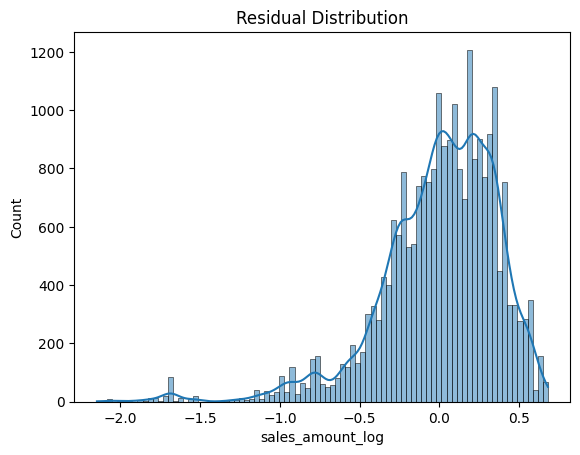

In [38]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

1. The residuals are not perfectly normally distributed<br>
2. Some patterns remain in the residual plot, suggesting that the model may not fully capture the underlying relationship<br>
3. This indicates that the relationship between predictors and sales may be nonlinear<br>
4. More advanced models should be explored to improve prediction accuracy.

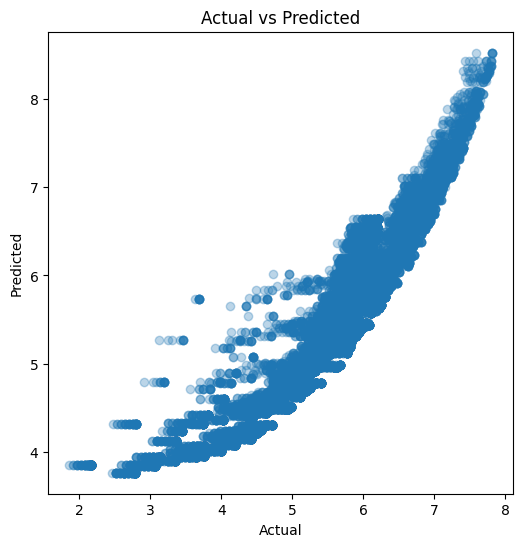

In [39]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

1. Most observations follow the overall trend of the diagonal line<br>
2. However, several points deviate significantly from the ideal line, indicating prediction errors<br>
3. The model tends to underpredict or overpredict certain sales values<br>
4. This suggests that a nonlinear model may better capture the complexity of the data

##### Plot shows nonlinear relationship. We need use polynomial regression

In [40]:
from sklearn.preprocessing import PolynomialFeatures

In [41]:
pipeline_poly = Pipeline([
    ('preprocessor', preprocessor),

    ('poly', PolynomialFeatures(degree=2, include_bias=False)),

    ('model', LinearRegression())
])

pipeline_poly.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [42]:
y_pred_poly = pipeline_poly.predict(x_test)

print(f"R² Score: {r2_score(y_test, y_pred_poly):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_poly):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_poly):.4f}")

R² Score: 0.9672
RMSE: 0.1862
MAE: 0.1384


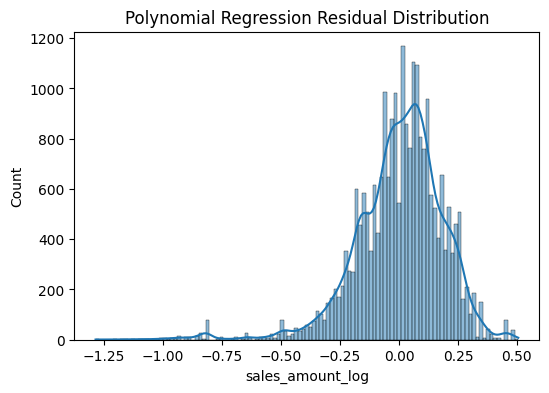

In [43]:
residuals_poly = y_test - y_pred_poly


# ======================================
# Residual Distribution
# ======================================

plt.figure(figsize=(6,4))

sns.histplot(residuals_poly, kde=True)

plt.title("Polynomial Regression Residual Distribution")

plt.show()

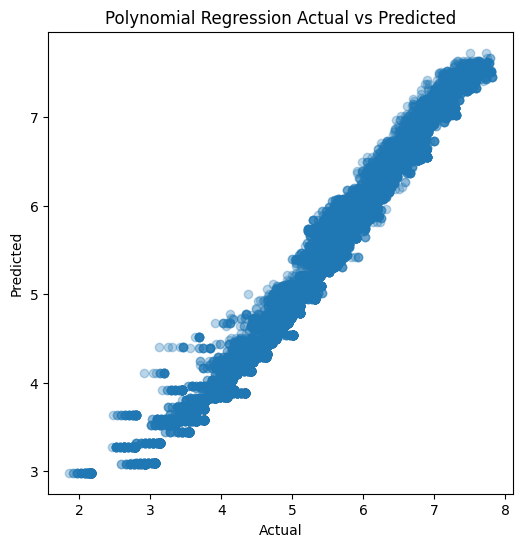

In [44]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_poly, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Polynomial Regression Actual vs Predicted")

plt.show()

In [45]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline_poly,
    x,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2 Scores:")
print(cv_scores)

print(f"\nMean CV R2: {cv_scores.mean():.4f}")
print(f"Std CV R2 : {cv_scores.std():.4f}")

Cross Validation R2 Scores:
[0.96703773 0.96745286 0.96633151 0.96698706 0.96653529]

Mean CV R2: 0.9669
Std CV R2 : 0.0004


In [46]:
import joblib

joblib.dump(
    pipeline_poly,
    'sales_prediction_model_poly.pkl'
)

['sales_prediction_model_poly.pkl']

In [47]:
loaded_model = joblib.load(
    'sales_prediction_model_poly.pkl'
)

In [48]:
new_data = pd.DataFrame({
    'unit_price': [300],
    'quantity': [2],
    'brand': ['Brand 1'],
    'category': ['Sports']
})

pred_log = loaded_model.predict(new_data)

pred_actual = np.expm1(pred_log)

print(pred_actual)

[594.89997012]


### Another Model

In [49]:
df2 = df1.copy()
df2.head()

,transaction_date,customer_gender,customer_age_group,customer_segment,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,sales_amount_log
0,2024-04-24,Other,35-44,Returning,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North,6.219894
1,2025-07-12,Other,45-54,New,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South,5.905798
2,2025-06-01,Male,55+,Returning,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South,3.366951
3,2025-08-26,Male,25-34,VIP,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South,5.161466
4,2024-12-10,Male,45-54,New,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central,5.562795


In [50]:
df2.columns

Index(['transaction_date', 'customer_gender', 'customer_age_group',
       'customer_segment', 'category', 'brand', 'quantity', 'unit_price',
       'discount_pct', 'sales_amount', 'payment_method', 'sales_channel',
       'region', 'sales_amount_log'],
      dtype='object')

In [51]:
df2.drop(columns=['sales_amount_log'], inplace=True)
df2.columns

Index(['transaction_date', 'customer_gender', 'customer_age_group',
       'customer_segment', 'category', 'brand', 'quantity', 'unit_price',
       'discount_pct', 'sales_amount', 'payment_method', 'sales_channel',
       'region'],
      dtype='object')

Text(0.5, 1.0, 'Spearman Correlation Heatmap')

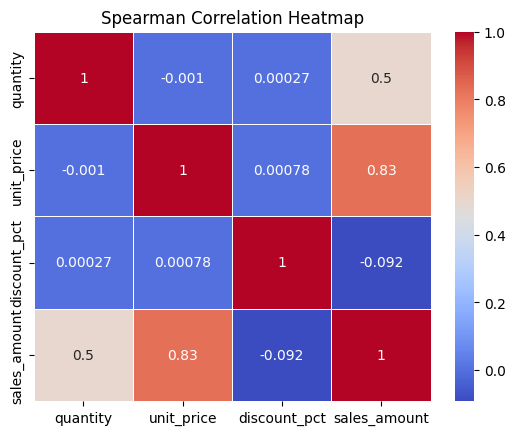

In [52]:
num_col2 = df2.select_dtypes(include=np.number).columns

sns.heatmap(df2[num_col2].corr(method='spearman'), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Spearman Correlation Heatmap')

In [53]:
corr = df2[num_col2].corr(method='spearman')['sales_amount'].sort_values(ascending=False)
corr

sales_amount    1.000000
unit_price      0.828776
quantity        0.496932
discount_pct   -0.092212
Name: sales_amount, dtype: float64

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# pilih numerical columns sahaja
v = df2[['unit_price', 'quantity', 'discount_pct']]

# optional: buang missing value
v = v.dropna()

# create VIF dataframe
vif_data = pd.DataFrame()
vif_data['feature'] = v.columns

# kira VIF
vif_data['VIF'] = [
    variance_inflation_factor(v.values, i)
    for i in range(len(v.columns))
]

# display
print(vif_data)

        feature       VIF
0    unit_price  2.235803
1      quantity  2.237555
2  discount_pct  1.355185


##### 1. We use spearman to see if any correlation between feature column for numerical and target which is sales_amount obviously have highly right skewed.<br>2. Again based on heatmap, only unit_price and quantity showed correlation with sales_amount while discount_pct not showed any correlation with sales_amount.<br>3. There is no any multicollinearity between unit price and quantity and discount pct<br> 4. We assume unit_price and quantity as a independent feature for the tree model

In [55]:
from scipy.stats import mannwhitneyu, kruskal

cat_col2 =df2.select_dtypes(include='object').columns
df2[cat_col2].columns

Index(['customer_gender', 'customer_age_group', 'customer_segment', 'category',
       'brand', 'payment_method', 'sales_channel', 'region'],
      dtype='object')

In [56]:
from scipy.stats import mannwhitneyu, kruskal

# categorical columns
cat_cols = df2.select_dtypes(include='object').columns

results = []

for col in cat_cols:
    
    # drop missing
    temp = df2[[col, 'sales_amount']].dropna()
    
    # unique groups
    groups = temp[col].unique()
    n_groups = len(groups)
    
    # create grouped sales data
    grouped_data = [
        temp[temp[col] == g]['sales_amount']
        for g in groups
    ]
    
    # =========================
    # 2 GROUPS → MANN WHITNEY
    # =========================
    
    if n_groups == 2:
        
        stat, p = mannwhitneyu(
            grouped_data[0],
            grouped_data[1],
            alternative='two-sided'
        )
        
        # effect size (rank biserial correlation)
        n1 = len(grouped_data[0])
        n2 = len(grouped_data[1])
        
        effect_size = 1 - ((2 * stat) / (n1 * n2))
        
        test_name = 'Mann-Whitney U'
    
    
    # =========================
    # >2 GROUPS → KRUSKAL
    # =========================
    
    elif n_groups > 2:
        
        stat, p = kruskal(*grouped_data)
        
        # effect size (eta squared)
        n = len(temp)
        
        effect_size = (stat - n_groups + 1) / (n - n_groups)
        
        test_name = 'Kruskal-Wallis'
    
    else:
        continue
    
    
    # store result
    results.append({
        'column': col,
        'n_groups': n_groups,
        'test': test_name,
        'p_value': round(p, 5),
        'effect_size': round(effect_size, 4)
    })

# result dataframe
results_df = pd.DataFrame(results)

# sort by p-value
results_df = results_df.sort_values('p_value')

print(results_df)

               column  n_groups            test  p_value  effect_size
3            category         8  Kruskal-Wallis  0.00000       0.0094
4               brand         3  Kruskal-Wallis  0.00000       0.0046
6       sales_channel         3  Kruskal-Wallis  0.02586       0.0000
0     customer_gender         3  Kruskal-Wallis  0.20610       0.0000
7              region         5  Kruskal-Wallis  0.28786       0.0000
1  customer_age_group         5  Kruskal-Wallis  0.61814      -0.0000
2    customer_segment         4  Kruskal-Wallis  0.65844      -0.0000
5      payment_method         5  Kruskal-Wallis  0.99290      -0.0000


#### 1. category, brand and sales_channel are correlated with sales_amount because p_value below than 0.05<br>2. among these 3 columns, only category and brand have effect size more than sales_channel dont have any effect size to sales_amount<br>3. we still assume category and brand as a independent categorical feature when run model

In [57]:
from sklearn.ensemble import RandomForestRegressor

xrf = df2[['unit_price', 'quantity', 'brand', 'category']]
yrf = df2['sales_amount']

In [58]:
xrf.head()

,unit_price,quantity,brand,category
0,313.53,2,Brand 1,Sports
1,366.16,1,Brand 3,Sports
2,27.99,1,Brand 3,Clothing
3,102.01,2,Brand 1,Beauty
4,259.55,1,Brand 1,Clothing


In [59]:
yrf.head()

0    501.65
1    366.16
2     27.99
3    173.42
4    259.55
Name: sales_amount, dtype: float64

In [60]:
xrf_train, xrf_test, yrf_train, yrf_test = train_test_split(xrf,yrf, test_size=0.2, random_state=42)

In [61]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['brand', 'category']),
    ], remainder='passthrough')

In [62]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline_rf.fit(xrf_train, yrf_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [63]:
y_predrf = pipeline_rf.predict(xrf_test)

print(f"R² Score: {r2_score(yrf_test, y_predrf):.4f}")
print(f"RMSE: {root_mean_squared_error(yrf_test, y_predrf):.4f}")
print(f"MAE: {mean_absolute_error(yrf_test, y_predrf):.4f}")

R² Score: 0.9835
RMSE: 45.5622
MAE: 26.8207


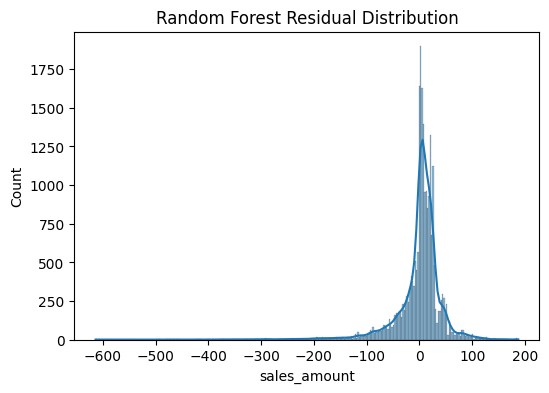

In [64]:
residuals_rf = yrf_test - y_predrf


# ======================================
# Residual Distribution
# ======================================

plt.figure(figsize=(6,4))
sns.histplot(residuals_rf, kde=True)

plt.title("Random Forest Residual Distribution")

plt.show()

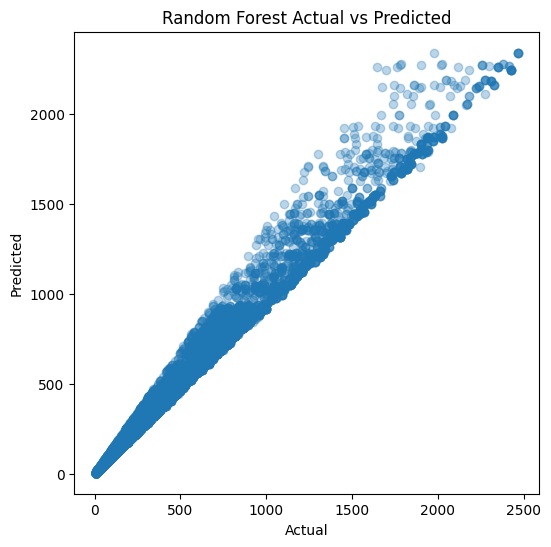

In [65]:
plt.figure(figsize=(6,6))

plt.scatter(yrf_test, y_predrf, alpha=0.3)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Random Forest Actual vs Predicted")

plt.show()

In [66]:
cv_scores_rf = cross_val_score(
    pipeline_rf,
    xrf,
    yrf,
    cv=5,
    scoring="r2"
)

print("Cross Validation R2 Scores:")
print(cv_scores_rf)
print()
print(f"Mean CV R2: {cv_scores_rf.mean():.4f}")
print(f"Std CV R2 : {cv_scores_rf.std():.4f}")

Cross Validation R2 Scores:
[0.98398331 0.9837191  0.98464566 0.9829645  0.98403236]

Mean CV R2: 0.9839
Std CV R2 : 0.0005


                         feature  importance
12           remainder__quantity    0.547728
11         remainder__unit_price    0.451872
2          onehot__brand_Brand 3    0.000060
8          onehot__category_Home    0.000046
7     onehot__category_Groceries    0.000044
0          onehot__brand_Brand 1    0.000040
10         onehot__category_Toys    0.000038
6   onehot__category_Electronics    0.000036
1          onehot__brand_Brand 2    0.000033
3        onehot__category_Beauty    0.000033
4         onehot__category_Books    0.000030
9        onehot__category_Sports    0.000025
5      onehot__category_Clothing    0.000016


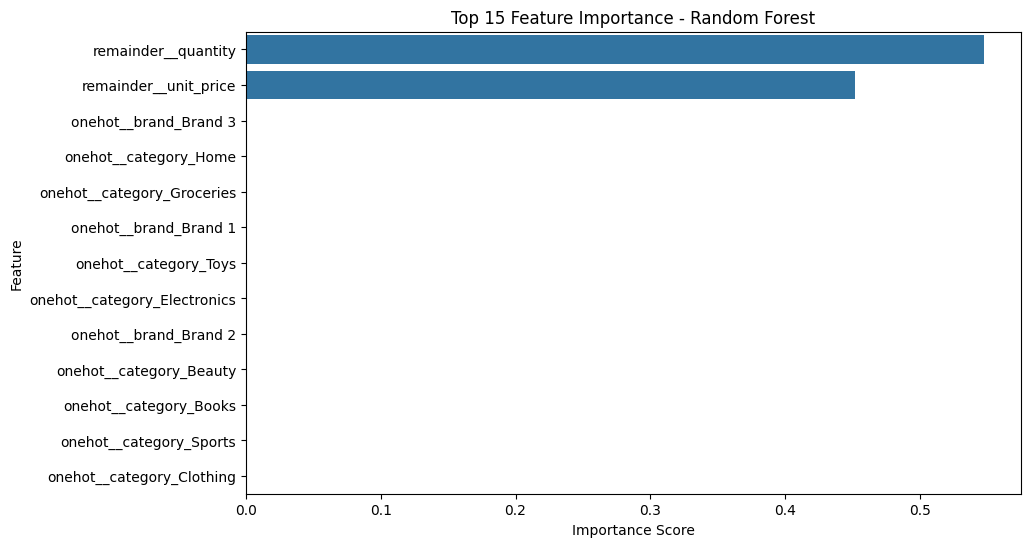

In [67]:
# ambil feature names selepas preprocessing
feature_names = pipeline_rf.named_steps[
    'preprocessor'
].get_feature_names_out()

# ambil feature importance dari random forest
importance = pipeline_rf.named_steps[
    'model'
].feature_importances_

# dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

# sort descending
feature_importance_df = feature_importance_df.sort_values(
    by='importance',
    ascending=False
)

# display
print(feature_importance_df)

# plot top 15
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df.head(15),
    x='importance',
    y='feature'
)

plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()